In [1]:
pwd

'D:\\樓上志偉\\2025實測\\notebooks'

In [2]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns

pd.options.mode.copy_on_write = True
fm.fontManager.addfont('..\\TaipeiSansTCBeta-Regular.ttf')
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = 'Taipei Sans TC Beta'

In [3]:
df_e = pd.read_csv('..\\data\\raw\\VECTO_engine\\220kW.vmap', skiprows=1, names=['engine_speed[rpm]', 'torque[Nm]', 'fuel_consumption[g/h]'])
# df_e = pd.read_csv('..\\data\\raw\\VECTO_engine\\325kW.vmap', skiprows=1, names=['engine_speed[rpm]', 'torque[Nm]', 'fuel_consumption[g/h]'])

# df_e

In [4]:
df_e['power[kW]'] = df_e['torque[Nm]'] * (df_e['engine_speed[rpm]'] / 60 * 2 * np.pi) / 1000
df_e['bsfc[g/kW-h]'] = df_e['fuel_consumption[g/h]'] / df_e['power[kW]']
df_e

,engine_speed[rpm],torque[Nm],fuel_consumption[g/h],power[kW],bsfc[g/kW-h]
0,600,-144.579000,0.000000,-9.084166,-0.000000
1,600,-44.579000,0.000000,-2.800981,-0.000000
2,600,0.000000,638.000000,0.000000,inf
3,600,70.000000,1601.240000,4.398230,364.064659
4,600,100.000000,2020.040000,6.283185,321.499351
...,...,...,...,...,...
152,2500,500.000000,27944.549815,130.899694,213.480635
153,2500,600.000000,33199.920608,157.079633,211.357259
154,2500,710.000000,39388.779557,185.877565,211.907120
155,2600,-146.132532,0.000000,-39.787704,-0.000000


In [5]:
list(df_e["bsfc[g/kW-h]"].sort_values())

[-0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 191.06168509062587,
 191.079729539458,
 191.11520792940462,
 191.1266209664872,
 191.28571829862338,
 191.89398085674554,
 193.28844990320016,
 193.3646492604809,
 193.99917591318575,
 194.010708384964,
 194.2377317119359,
 194.25298475544466,
 194.42104874625872,
 194.6266101788431,
 194.6457820035353,
 194.67787340880986,
 194.75928218892543,
 194.78655649217654,
 194.89558554974846,
 195.0688580916299,
 195.14793754610488,
 195.3233468867299,
 195.3436846531145,
 195.76488012982838,
 196.29670679551992,
 196.40285679661392,
 196.7950480470356,
 196.8876563757585,
 197.15237917512297,
 197.25509667220797,
 197.28044410476397,
 197.35482408106756,
 197.39052946926648,
 197.6401681828152,
 199.41962299894362,
 199.45051004538297,
 199.9958350669481,
 200.13443255692897,
 200.21345476418054,
 200.5594633326493,
 200.69104557108

<Axes: >

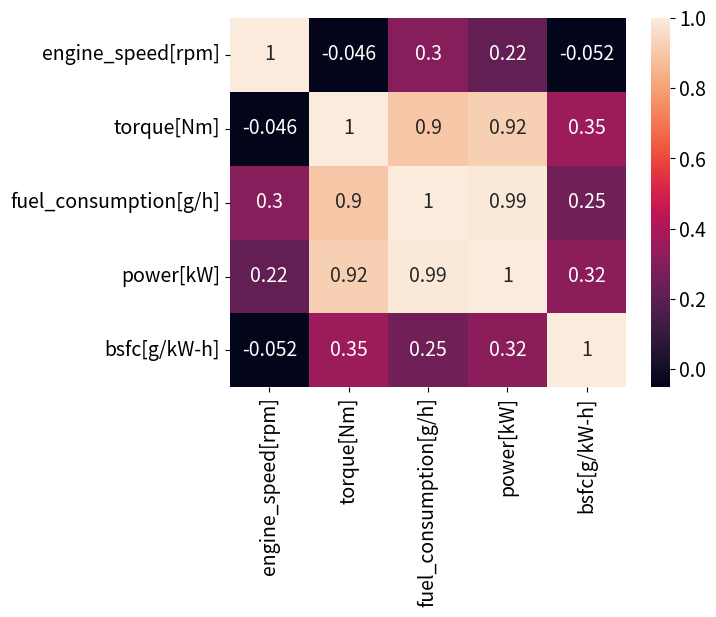

In [6]:
sns.heatmap(df_e[['engine_speed[rpm]', 'torque[Nm]', 'fuel_consumption[g/h]', 'power[kW]', 'bsfc[g/kW-h]']].corr(), annot=True)

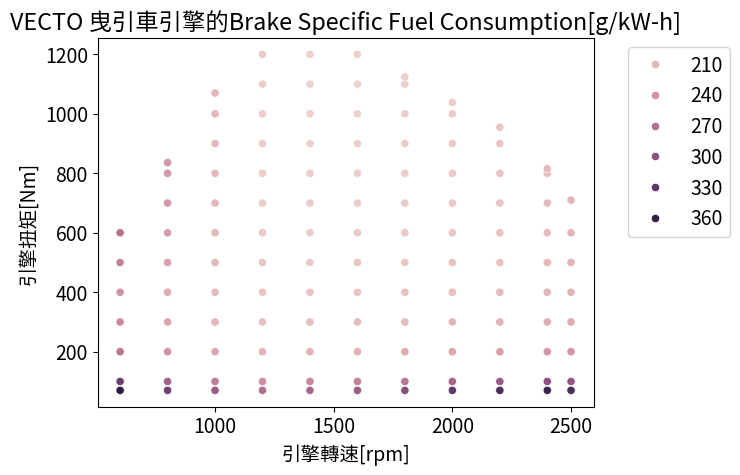

In [7]:
fig = plt.figure()
sns.scatterplot(data=df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)],
                x="engine_speed[rpm]",
                y="torque[Nm]",
                hue="bsfc[g/kW-h]")

# plt.title(f"VECTO 26噸大貨車引擎的Brake Specific Fuel Consumption[g/kW-h]")
plt.title(f"VECTO 曳引車引擎的Brake Specific Fuel Consumption[g/kW-h]")
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

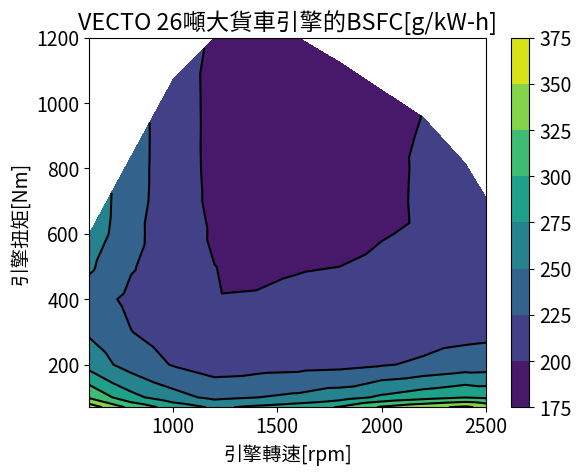

In [8]:
fig = plt.figure()
tcf = plt.tricontourf(df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)]["engine_speed[rpm]"],
                      df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)]["torque[Nm]"],
                      df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)]["bsfc[g/kW-h]"])
fig.colorbar(tcf)
plt.tricontour(df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)]["engine_speed[rpm]"],
               df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)]["torque[Nm]"],
               df_e[(df_e["bsfc[g/kW-h]"]<1000) & (df_e["bsfc[g/kW-h]"]>0)]["bsfc[g/kW-h]"],
               colors='k')
plt.title(f"VECTO 26噸大貨車引擎的BSFC[g/kW-h]")
# plt.title(f"VECTO 曳引車引擎的BSFC[g/kW-h]")
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')
plt.show()